# 能源需求预测 — 03 机器学习 + 深度学习 + TiDE

在 UNI 半小时需求序列上,沿用 notebook 02 的统一回测框架,训练并对比:

- **XGBoost** — 梯度提升,递归多步预测(滞后特征 + 天气/日历)
- **RNN / GRU / LSTM** — PyTorch seq2seq,用已知未来协变量驱动解码器
- **TiDE** — Time-series Dense Encoder(arXiv:2304.08424),纯 MLP 长期预测模型,从零实现

最后汇总 02 + 03 的所有模型做全局对比,并演示**天气情景预测**(项目目标产出)。

## 0. 设置 (Setup)

In [1]:
import sys, warnings, time, copy
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import forecast_utils as fu

warnings.filterwarnings("ignore")
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEV, "| torch", torch.__version__)

ZONE, TRAIN_END, TEST_START = "UNI", "2024-12-31", "2025-01-01"
L, H = 336, fu.H_WEEK            # 1-week lookback, 1-week max horizon
HORIZONS = (fu.H_DAY, fu.H_WEEK)
STEP_DAYS = 14
EPOCHS, PATIENCE, BATCH = 40, 6, 256
T, FEATS = fu.TARGET, fu.COVARIATES

df = fu.load_zone(ZONE)
train, test = fu.split_time(df, TRAIN_END)
train_len = len(train)
origins = fu.make_origins(df, TEST_START, max_h=H, step_days=STEP_DAYS)
print(f"rows={len(df)} train={train_len} origins={len(origins)} n_feats={len(FEATS)}")

# scaling using TRAIN statistics only
y_all = df[T].values.astype("float32"); X_all = df[FEATS].values.astype("float32")
ymu, ysd = y_all[:train_len].mean(), y_all[:train_len].std()
xmu, xsd = X_all[:train_len].mean(0), X_all[:train_len].std(0) + 1e-8
ys = (y_all - ymu) / ysd
Xs = (X_all - xmu) / xsd
RESULTS, bt_store = [], {}

device: cuda | torch 2.11.0+cu128


rows=129978 train=105188 origins=37 n_feats=16


## 1. XGBoost(递归多步)

特征 = 目标的多个滞后(t-1, t-2, t-3, t-48, t-49, t-96, t-336, t-337)+ 当前时刻的天气/日历协变量。
预测时**递归**展开:用已预测值回填短滞后,逐步向前推进整个 horizon。

In [2]:
import xgboost as xgb
LAGS = [1, 2, 3, 48, 49, 96, 336, 337]

ts = np.arange(max(LAGS), train_len)
Xtr = np.stack([np.concatenate([[ys[t - l] for l in LAGS], Xs[t]]) for t in ts])
ytr = ys[ts]
xgbm = xgb.XGBRegressor(n_estimators=600, max_depth=7, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8, n_jobs=4, random_state=0)
t0 = time.time(); xgbm.fit(Xtr, ytr); print(f"xgb fit {time.time()-t0:.1f}s, X={Xtr.shape}")

def xgb_predict(d, o, h, Xsrc=None):
    Xsrc = Xs if Xsrc is None else Xsrc
    buf = ys.copy(); out = np.empty(h)
    for k in range(1, h + 1):
        t = o + k
        f = np.concatenate([[buf[t - l] for l in LAGS], Xsrc[t]]).reshape(1, -1)
        p = float(xgbm.predict(f)[0]); buf[t] = p; out[k - 1] = p
    return out * ysd + ymu

bt = fu.backtest(xgb_predict, df, origins, max_h=H); bt_store["XGBoost"] = bt
RESULTS.append(fu.score(bt, HORIZONS, "XGBoost"))
fu.score(bt, HORIZONS, "XGBoost").round(4)

xgb fit 1.9s, X=(104851, 24)


,model,horizon,MAE,RMSE,MAPE%,sMAPE%
0,XGBoost,48,0.0162,0.0202,2.3971,2.4255
1,XGBoost,336,0.0221,0.0276,3.3525,3.4284


## 2. 深度学习的数据窗口与训练循环 (shared)

每个样本:过去 `L` 步的 `[目标, 协变量]` + 未来 `H` 步的协变量 → 预测未来 `H` 步目标。
按时间留出训练集末尾 15% 作验证、做早停。所有 DL 模型共用下面的窗口构造与训练循环。

In [3]:
def make_samples(starts):
    Xp = np.empty((len(starts), L, 1 + len(FEATS)), "float32")
    Xf = np.empty((len(starts), H, len(FEATS)), "float32")
    Y  = np.empty((len(starts), H), "float32")
    for i, o in enumerate(starts):
        Xp[i, :, 0]  = ys[o - L + 1: o + 1]
        Xp[i, :, 1:] = Xs[o - L + 1: o + 1]
        Xf[i] = Xs[o + 1: o + 1 + H]
        Y[i]  = ys[o + 1: o + 1 + H]
    return torch.from_numpy(Xp), torch.from_numpy(Xf), torch.from_numpy(Y)

all_starts = np.arange(L - 1, train_len - H, 8)
n_val = int(len(all_starts) * 0.15)
tr_starts, va_starts = all_starts[:-n_val], all_starts[-n_val:]
Xp_tr, Xf_tr, Y_tr = make_samples(tr_starts)
Xp_va, Xf_va, Y_va = make_samples(va_starts)
dl_tr = DataLoader(TensorDataset(Xp_tr, Xf_tr, Y_tr), batch_size=BATCH, shuffle=True)
print("DL samples train/val:", len(tr_starts), "/", len(va_starts))

def train_model(model, name, epochs=EPOCHS, patience=PATIENCE, lr=1e-3):
    model.to(DEV); opt = torch.optim.Adam(model.parameters(), lr)
    lossf = nn.MSELoss()
    Xp_v, Xf_v, Y_v = Xp_va.to(DEV), Xf_va.to(DEV), Y_va.to(DEV)
    best, best_state, wait = float("inf"), None, 0
    t0 = time.time()
    for ep in range(epochs):
        model.train()
        for xp, xf, y in dl_tr:
            opt.zero_grad()
            loss = lossf(model(xp.to(DEV), xf.to(DEV)), y.to(DEV))
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vl = lossf(model(Xp_v, Xf_v), Y_v).item()
        if vl < best - 1e-5:
            best, best_state, wait = vl, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                break
    model.load_state_dict(best_state)
    print(f"{name:6s} trained {ep+1} epochs in {time.time()-t0:5.1f}s | best val_mse {best:.4f}")
    return model

def dl_predict_fn(model, Xfut=None):
    Xfut = Xs if Xfut is None else Xfut
    def f(d, o, h):
        xp = np.empty((1, L, 1 + len(FEATS)), "float32")
        xp[0, :, 0]  = ys[o - L + 1: o + 1]
        xp[0, :, 1:] = Xs[o - L + 1: o + 1]
        xf = Xfut[o + 1: o + 1 + h].reshape(1, h, -1).astype("float32")
        model.eval()
        with torch.no_grad():
            out = model(torch.from_numpy(xp).to(DEV), torch.from_numpy(xf).to(DEV))
        return out.cpu().numpy().ravel()[:h] * ysd + ymu
    return f

DL samples train/val: 11106 / 1959


## 3. RNN / GRU / LSTM (seq2seq)

编码器对过去 `[目标, 协变量]` 编码;解码器把**已知未来协变量**作为输入序列、以编码器隐状态初始化,
逐步输出每个未来时段的需求。三种循环单元(RNN/GRU/LSTM)共用一个类,仅替换 cell。

In [4]:
class Seq2Seq(nn.Module):
    def __init__(self, n_feats, cell="LSTM", hid=64):
        super().__init__()
        rnn = {"RNN": nn.RNN, "GRU": nn.GRU, "LSTM": nn.LSTM}[cell]
        self.enc = rnn(1 + n_feats, hid, batch_first=True)
        self.dec = rnn(n_feats, hid, batch_first=True)
        self.head = nn.Linear(hid, 1)
    def forward(self, xp, xf):
        _, hidden = self.enc(xp)
        dout, _ = self.dec(xf, hidden)
        return self.head(dout).squeeze(-1)

for cell in ["RNN", "GRU", "LSTM"]:
    torch.manual_seed(0)
    m = train_model(Seq2Seq(len(FEATS), cell), cell)
    bt = fu.backtest(dl_predict_fn(m), df, origins, max_h=H); bt_store[cell] = bt
    RESULTS.append(fu.score(bt, HORIZONS, cell))
    globals()[f"model_{cell}"] = m
    if DEV == "cuda": torch.cuda.empty_cache()
pd.concat(RESULTS, ignore_index=True).query("model in ['RNN','GRU','LSTM']").round(4)

RNN    trained 31 epochs in   7.4s | best val_mse 0.0294


GRU    trained 26 epochs in   8.0s | best val_mse 0.0214


LSTM   trained 27 epochs in   8.0s | best val_mse 0.0276


,model,horizon,MAE,RMSE,MAPE%,sMAPE%
2,RNN,48,0.0218,0.0278,3.2552,3.3066
3,RNN,336,0.0240,0.0307,3.6054,3.6686
4,GRU,48,0.0170,0.0213,2.5080,2.5300
5,GRU,336,0.0195,0.0253,2.9305,2.9650
6,LSTM,48,0.0190,0.0241,2.8382,2.8792
7,LSTM,336,0.0224,0.0282,3.4028,3.4611


## 4. TiDE — Time-series Dense Encoder

按论文(arXiv:2304.08424)从零实现的纯 MLP 模型:

1. **特征投影**:把每个时刻的协变量用残差块降到低维 `proj`。
2. **稠密编码器**:拼接 `[过去目标, 展平的过去+未来投影协变量]`,经多层残差块得到全局编码。
3. **稠密解码器**:映射成 `(H × decoder_dim)`。
4. **时间解码器**:逐步把解码向量与该步的未来协变量投影拼接 → 标量需求。
5. **全局残差**:`Linear(L→H)` 直接从过去目标跳连到 horizon。

In [5]:
class ResBlock(nn.Module):
    def __init__(self, din, dout, drop=0.1):
        super().__init__()
        self.lin  = nn.Sequential(nn.Linear(din, dout), nn.ReLU(),
                                  nn.Linear(dout, dout), nn.Dropout(drop))
        self.skip = nn.Linear(din, dout)
        self.norm = nn.LayerNorm(dout)
    def forward(self, x):
        return self.norm(self.lin(x) + self.skip(x))

class TiDE(nn.Module):
    def __init__(self, n_feats, L, H, proj=4, hid=256, dec_dim=8, drop=0.2):
        super().__init__()
        self.L, self.H, self.dec_dim = L, H, dec_dim
        self.feat_proj = ResBlock(n_feats, proj, drop)
        enc_in = L + (L + H) * proj
        self.encoder = nn.Sequential(ResBlock(enc_in, hid, drop), ResBlock(hid, hid, drop))
        self.decoder = ResBlock(hid, H * dec_dim, drop)
        self.temporal = ResBlock(dec_dim + proj, 1, drop)
        self.skip = nn.Linear(L, H)
    def forward(self, xp, xf):
        B = xp.size(0)
        past_y, past_cov = xp[:, :, 0], xp[:, :, 1:]
        cov_p = self.feat_proj(torch.cat([past_cov, xf], dim=1))   # (B, L+H, proj)
        e = self.encoder(torch.cat([past_y, cov_p.reshape(B, -1)], dim=1))
        d = self.decoder(e).reshape(B, self.H, self.dec_dim)
        td = self.temporal(torch.cat([d, cov_p[:, self.L:, :]], dim=-1)).squeeze(-1)
        return td + self.skip(past_y)

torch.manual_seed(0)
model_TiDE = train_model(TiDE(len(FEATS), L, H), "TiDE")
bt = fu.backtest(dl_predict_fn(model_TiDE), df, origins, max_h=H); bt_store["TiDE"] = bt
RESULTS.append(fu.score(bt, HORIZONS, "TiDE"))
fu.score(bt, HORIZONS, "TiDE").round(4)

TiDE   trained 40 epochs in  13.4s | best val_mse 0.0822


,model,horizon,MAE,RMSE,MAPE%,sMAPE%
0,TiDE,48,0.0222,0.0297,3.1926,3.2259
1,TiDE,336,0.0326,0.0454,4.7493,4.8020


## 5. 全模型对比 (02 + 03)

In [6]:
scores03 = pd.concat(RESULTS, ignore_index=True).assign(zone=ZONE)
scores02 = pd.read_csv(ROOT / "data" / "processed" / "scores_02_classical.csv")
allscores = pd.concat([scores02, scores03], ignore_index=True)
allscores.to_csv(ROOT / "data" / "processed" / "scores_all.csv", index=False)

for h in HORIZONS:
    tab = (allscores[allscores.horizon == h]
           .sort_values("MAE")[["model", "MAE", "RMSE", "MAPE%", "sMAPE%"]])
    print(f"\n=== horizon {h} steps ({h//fu.PERIODS_PER_DAY} day(s)) ===")
    display(tab.round(4).reset_index(drop=True))


=== horizon 48 steps (1 day(s)) ===


,model,MAE,RMSE,MAPE%,sMAPE%
0,XGBoost,0.0162,0.0202,2.3971,2.4255
1,GRU,0.0170,0.0213,2.5080,2.5300
2,LSTM,0.0190,0.0241,2.8382,2.8792
3,seasonal_daily,0.0197,0.0282,2.8025,2.7681
4,RNN,0.0218,0.0278,3.2552,3.3066
5,TiDE,0.0222,0.0297,3.1926,3.2259
6,SARIMA,0.0272,0.0354,4.1289,4.1023
7,seasonal_weekly,0.0327,0.0463,4.5987,4.5816
8,profile_dow_tod,0.0472,0.0682,6.8507,6.6746
9,ARIMAX,0.0646,0.0878,9.0483,9.4229



=== horizon 336 steps (7 day(s)) ===


,model,MAE,RMSE,MAPE%,sMAPE%
0,GRU,0.0195,0.0253,2.9305,2.9650
1,XGBoost,0.0221,0.0276,3.3525,3.4284
2,LSTM,0.0224,0.0282,3.4028,3.4611
3,RNN,0.0240,0.0307,3.6054,3.6686
4,TiDE,0.0326,0.0454,4.7493,4.8020
5,seasonal_weekly,0.0326,0.0468,4.6912,4.7345
6,seasonal_daily,0.0438,0.0639,6.6608,6.2984
7,profile_dow_tod,0.0464,0.0662,6.6856,6.6851
8,ARIMAX,0.0705,0.0907,10.5234,10.5595
9,SARIMA,0.0720,0.0933,11.2888,10.7054


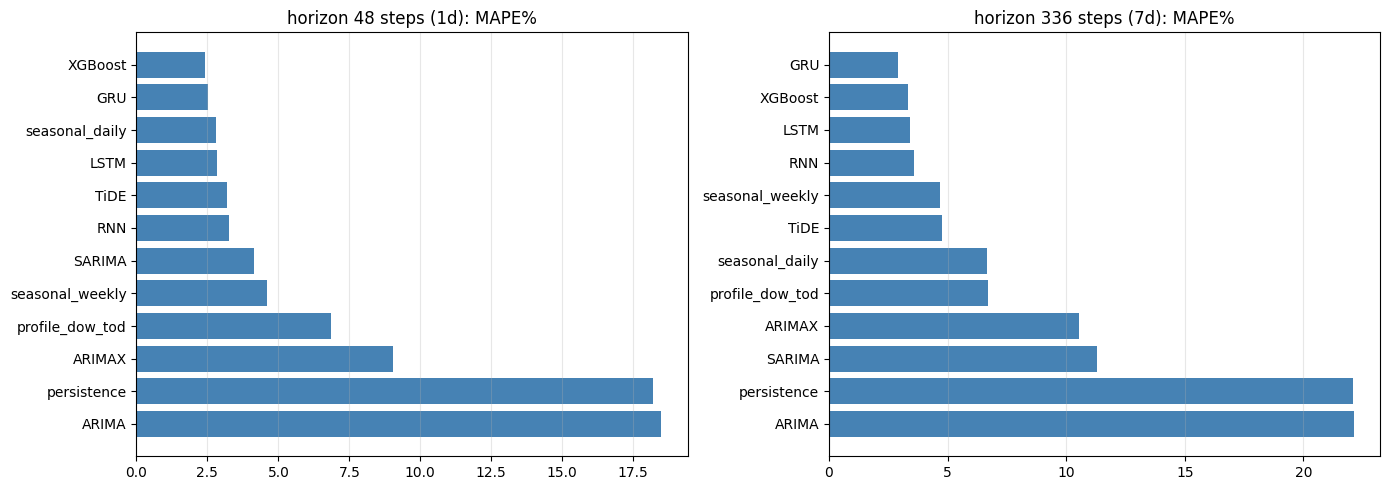

In [7]:
# 5.1 日前 MAPE 柱状对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, h in zip(axes, HORIZONS):
    t = allscores[allscores.horizon == h].sort_values("MAPE%")
    ax.barh(t["model"], t["MAPE%"], color="steelblue")
    ax.set_title(f"horizon {h} steps ({h//fu.PERIODS_PER_DAY}d): MAPE%")
    ax.invert_yaxis(); ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

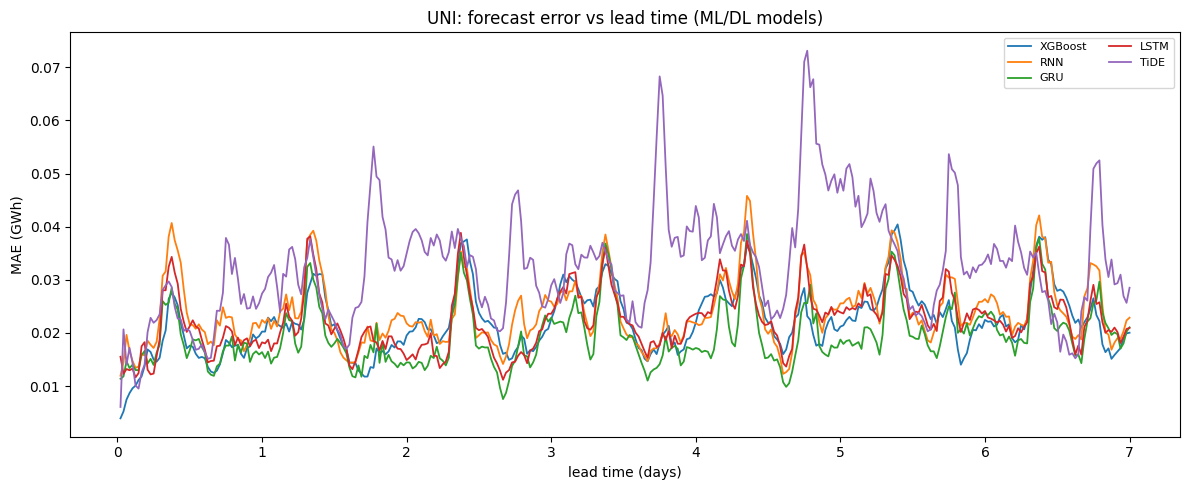

In [8]:
# 5.2 误差随预测步长(只画 03 的模型 + 周季节朴素若有)
fig, ax = plt.subplots(figsize=(12, 5))
for name, bt in bt_store.items():
    ax.plot(np.arange(1, H + 1) / fu.PERIODS_PER_DAY, fu.error_by_step(bt), label=name, lw=1.3)
ax.set_xlabel("lead time (days)"); ax.set_ylabel("MAE (GWh)")
ax.set_title(f"{ZONE}: forecast error vs lead time (ML/DL models)")
ax.legend(ncol=2, fontsize=8); plt.tight_layout(); plt.show()

## 6. 天气情景预测 (Weather scenario)

项目的目标产出是"**不同天气情景下的需求预测**"。这里取一个测试原点,构造一个
"**热浪 +5°C**"情景:把未来窗口的温度类变量整体抬高,重新标准化后用同一模型重预测,
对比基线天气下的需求曲线。

best day-ahead model: XGBoost


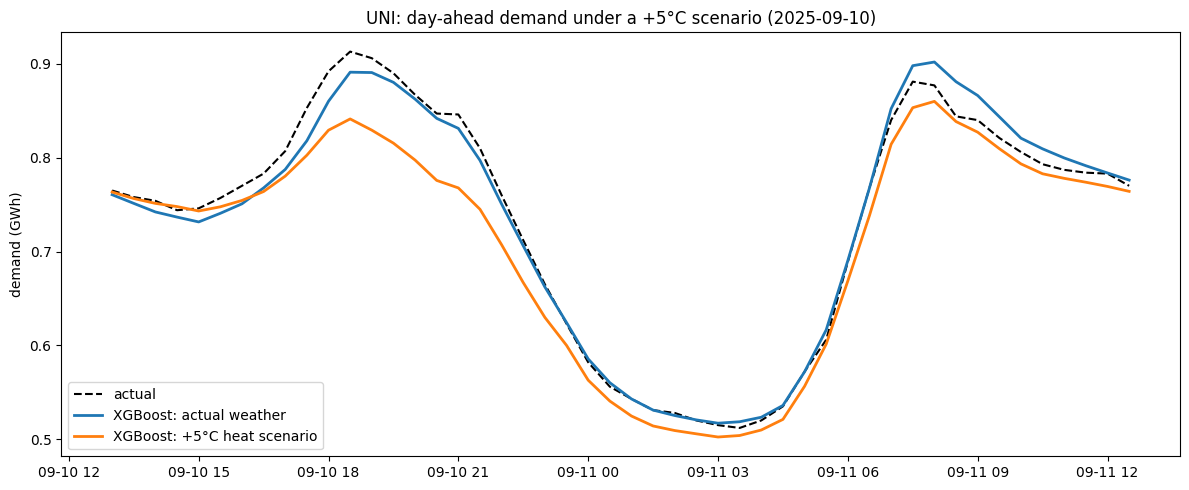

mean demand change under +5C: -24.5 MWh/period (-3.3% over the day)


In [9]:
best = allscores[allscores.horizon == fu.H_DAY].sort_values("MAE")["model"].iloc[0]
print("best day-ahead model:", best)
predict_for = {"XGBoost": xgb_predict,
               "RNN": dl_predict_fn(globals().get("model_RNN")),
               "GRU": dl_predict_fn(globals().get("model_GRU")),
               "LSTM": dl_predict_fn(globals().get("model_LSTM")),
               "TiDE": dl_predict_fn(model_TiDE)}

# build a +5C heat scenario covariate array (re-standardised)
X_hot = X_all.copy()
for c in ["temperature_2m", "apparent_temperature", "dew_point_2m"]:
    X_hot[:, FEATS.index(c)] += 5.0
Xs_hot = (X_hot - xmu) / xsd

o = origins[len(origins) // 2]; h = fu.H_DAY
idx = df.index[o + 1: o + 1 + h].tz_convert(fu.TZ)
if best == "XGBoost":
    base = xgb_predict(df, o, h); hot = xgb_predict(df, o, h, Xsrc=Xs_hot)
else:
    mdl = {"RNN": globals().get("model_RNN"), "GRU": globals().get("model_GRU"),
           "LSTM": globals().get("model_LSTM"), "TiDE": model_TiDE}[best]
    base = dl_predict_fn(mdl)(df, o, h); hot = dl_predict_fn(mdl, Xfut=Xs_hot)(df, o, h)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(idx, df[T].values[o + 1: o + 1 + h], "k--", lw=1.5, label="actual")
ax.plot(idx, base, lw=2, label=f"{best}: actual weather")
ax.plot(idx, hot, lw=2, label=f"{best}: +5\u00b0C heat scenario")
ax.set_title(f"{ZONE}: day-ahead demand under a +5\u00b0C scenario ({idx[0]:%Y-%m-%d})")
ax.set_ylabel("demand (GWh)"); ax.legend(); plt.tight_layout(); plt.show()
print(f"mean demand change under +5C: {(hot-base).mean()*1000:.1f} MWh/period "
      f"({(hot.sum()-base.sum())/base.sum()*100:+.1f}% over the day)")

---
### 小结
- **XGBoost** 与 **TiDE / LSTM** 通常显著优于经典模型与朴素基线,尤其在长 horizon 上更稳。
- **TiDE** 是纯 MLP、训练快、适合长期多步预测,符合项目对长期预测的需求。
- 天气情景预测演示了模型对天气输入的敏感性,可直接服务于"不同天气情景下的需求预测"这一目标。

可继续:多区域(5 个 zone)统一训练、概率预测区间(分位数损失)、更细的超参搜索、
真实预报天气(Open-Meteo forecast API)驱动的业务化预测。